# Group 2604 Members

| Name | Family Name | Matriculation Number |
|------|-------------|----------------------|
| Luca | Di Turi | 2196579 |
| Alessandro | Turino | 2205737 |
| Mattia | Ziglioli | 2198835 |
| Andrea | Marchetti | 2197526 |

In [33]:
#In the exercise solutions we kept the same dataset used during the lesson, i.e. the one dimensional timeserie with 3 different signal classes.

### CNNs applied to time series

In [43]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D, GlobalMaxPooling1D

%run plot.py
#%run plot1.py   #same as plo.py but allows to visualize more data

### Read data

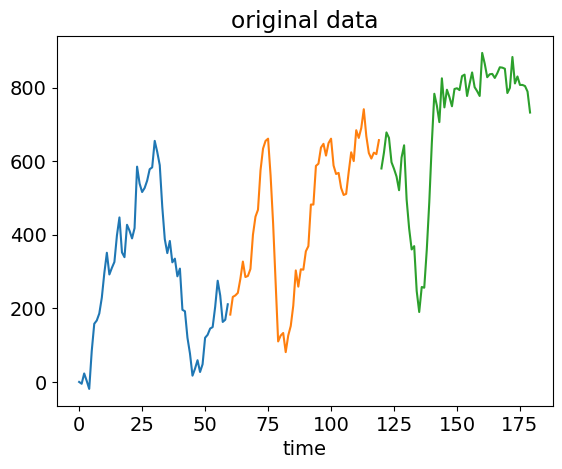

data:  10000


In [44]:
str0 = 'ts_L60_Z12_A500_DX50_bias5_N10000.dat'
fnamex='DATA/x_'+str0
fnamey='DATA/y_ts_L60_Z12_A500_DX50_bias5_N10000.dat'

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
#x50 = np.loadtxt('DATA/x_ts_L60_Z12_A50_DX50_bias5_N10000.dat', delimiter=" ",dtype=float)
x100 = np.loadtxt('DATA/x_ts_L60_Z12_A100_DX50_bias5_N10000.dat', delimiter=" ",dtype=float)
x200 = np.loadtxt('DATA/x_ts_L60_Z12_A200_DX50_bias5_N10000.dat', delimiter=" ",dtype=float)
x300 = np.loadtxt('DATA/x_ts_L60_Z12_A300_DX50_bias5_N10000.dat', delimiter=" ",dtype=float)
x400 = np.loadtxt('DATA/x_ts_L60_Z12_A400_DX50_bias5_N10000.dat', delimiter=" ",dtype=float)
# number of samples, number of features
N,L = len(x), len(x[0])

Show_data(x,L,"original data")

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3    # y.argmax() - y.argmin() +1
print('data: ',N)

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1. # y contains one-hot encoding

### Split train-validation and rescale

In [45]:
# split into training and validation sets
def split(x, y, N, L, n_class, print_opt = False):
    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
        
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)

    # rescale with variance on the training set
    for i in range(N_train):
        #x_train[i] = (x_train[i]-xm_train[i])/ std_train[i] #not good, std_train is very variable across samples
         #x_train[i] = (x_train[i]-xm_train[i])/ 400 #crude rescaling, variance should be used
         x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    for i in range(N_val):
        #x_val[i] = (x_val[i]-xm_val[i])/ std_val[i]
        #x_val[i] = (x_val[i]-xm_val[i])/ 400
        x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
    if (print_opt == 1):
        print(x_train.shape)
        print('N_train=',N_train,'  N_val=',N_val,'  L=',L,'  n_class=',n_class)
        print('std_train average and mean:',max(std_train), min(std_train), std_train.mean(axis=0))
        print('std_val average and mean:',max(std_val), min(std_val), std_val.mean(axis=0))
        Show_data(x_train,L,"rescaled train data")
        Show_data(x_val,L,"rescaled validation data")
        
    # Keras wants an additional dimension with a 1 at the end
    x_train = x_train.reshape(x_train.shape[0], L, 1)
    x_val =  x_val.reshape(x_val.shape[0], L, 1)
    input_shape = (L, 1) # number of features, number of channels (1 for 1D data)
    return x_train, x_val, y_train, y_val, input_shape
#

(8000, 60)
N_train= 8000   N_val= 2000   L= 60   n_class= 3
std_train average and mean: 588.25397835931 44.84287073276593 201.46657645528722
std_val average and mean: 569.9090424503428 55.06717110341998 201.92178219610327


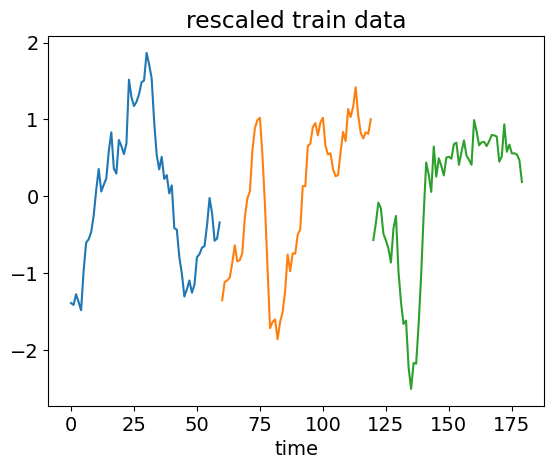

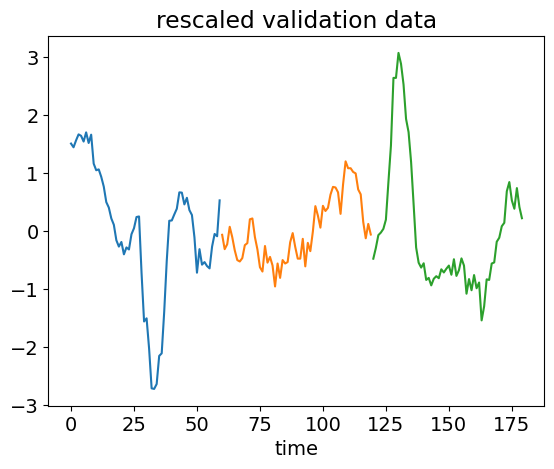

In [46]:
x_train, x_val, y_train, y_val, input_shape = split(x, y, N, L, n_class, True)     #set the last var. to 1 to print and show some features of the split dataset (0 to hide them)


#x_train=x_train.astype("float32")
#y_train=y_train.astype("float32")
#x_val=x_val.astype("float32")
#y_val=y_val.astype("float32")

## Convolutional NN (definition and initialization of the different models)

In [47]:
# ...LESSON ...
# reproducibility
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

def NN(input_shape, NCONV=1, NF = 5, regularizer = 2, lambda_par = 0.2, print_opt = False, n_class = 3):
    ## from keras import regularizers, initializers
    if regularizer == 1:
        reg = tf.keras.regularizers.l1(lambda_par)
    elif regularizer == 2:
        reg = tf.keras.regularizers.l2(lambda_par)
    elif regularizer == 3:
        reg = tf.keras.regularizers.l1_l2(lambda_par)

    #reg = regularizers.l1(0.1)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                            seed=None)
    #NCONV = 1 #swtich between 1 and 2 CNNs
    #NF = 5 #number of filters

    # challenge: at most 600 tunable parameters
    model = Sequential()
    #
    if NCONV==1:
        # -----2-----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                         kernel_initializer=ini, 
                         kernel_regularizer=reg,
                         activation='relu', 
                         input_shape=input_shape))
        #model.add(MaxPooling1D(3))
        model.add(AveragePooling1D(5))
        model.add(Conv1D(filters=5, kernel_size=7, 
                         activation='relu'))
        model.add(Flatten())
        model.add(Dense(12, activation='relu'))
        model.add(Dropout(0.2))
    #
    if NCONV==2:
        # -----1-----
        model.add(Conv1D(filters=NF, kernel_size=11, 
                         kernel_initializer=ini, 
                         kernel_regularizer=reg, ######## TRY WITHOUT !
                         activation='relu', input_shape=input_shape))
        #model.add(MaxPooling1D(3))
        model.add(AveragePooling1D(5))
        model.add(Flatten())
        model.add(Dense(9, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(6, activation='relu'))
        model.add(Dropout(0.2))
        #model.add(Dense(10, activation='relu'))
        #model.add(Dropout(0.3))
    #
    if NCONV == 3:
        # Best model 2020-2021: 3 conv, no pooling, global max pooling
        model.add(Conv1D(filters=6, kernel_size=3,
                         kernel_initializer=ini,
                         kernel_regularizer=reg,
                         activation='relu',
                         input_shape=input_shape))   # output: (None, 58, 6)  params: 24
    
        model.add(Conv1D(filters=8, kernel_size=9,
                         activation='relu'))          # output: (None, 50, 8)  params: 440
    
        model.add(Conv1D(filters=4, kernel_size=3,
                         activation='relu'))          # output: (None, 48, 4)  params: 100
    
        model.add(GlobalMaxPooling1D())               # output: (None, 4)      params: 0
        model.add(Flatten())                          # output: (None, 4)      params: 0
        # Dense finale già aggiunto sotto: Dense(n_class) → params: 4×3+3 = 15

    model.add(Dense(n_class, activation='softmax')) # softmax !
    

    if (print_opt == True):
        print('----- Model',NCONV,'-----')
        print(model.summary())
    
    # optimizers
    # .SGD(lr=0.01, momentum=0.9, nesterov=True) # decay=1e-6,
    # .RMSprop()
    # .Nadam()
    opt = tf.keras.optimizers.Adam()
    
    # compile the model
    # categorical_crossentropy, 3 output nodes
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=opt,metrics=['accuracy'])
    return model, NCONV

In [48]:
model, NCONV = NN(input_shape, NCONV=1, print_opt = True)

----- Model 1 -----


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 50, 5)          │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_3             │ (None, 10, 5)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 4, 5)           │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 12)             │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531 (2.07 KB)

 Trainable params: 531 (2.07 KB)

 Non-trainable params: 0 (0.00 B)

None


In [49]:
model.layers

[<Conv1D name=conv1d_20, built=True>,
 <AveragePooling1D name=average_pooling1d_3, built=True>,
 <Conv1D name=conv1d_21, built=True>,
 <Flatten name=flatten_7, built=True>,
 <Dense name=dense_11, built=True>,
 <Dropout name=dropout_4, built=True>,
 <Dense name=dense_12, built=True>]

In [50]:
def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0] # weights
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()

(11, 1, 5)
(5, 1, 11)


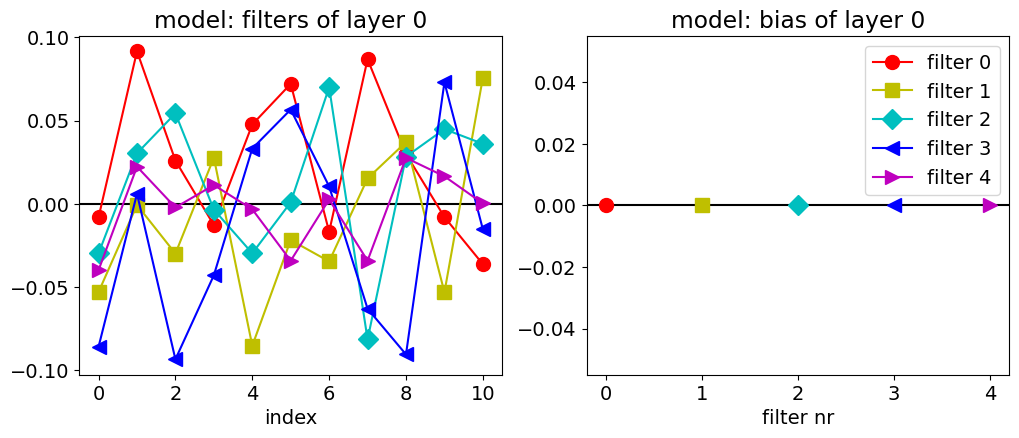

(7, 5, 5)
(5, 5, 7)


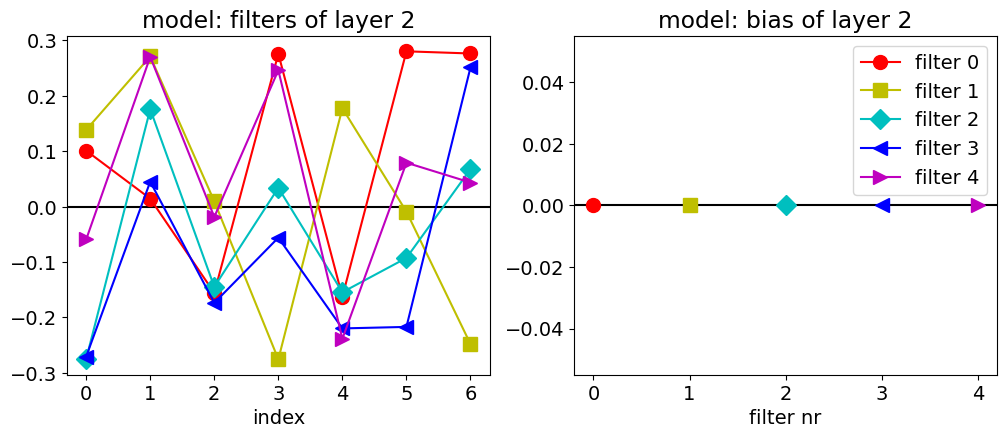

In [51]:
Show_weights(model,0)
Show_weights(model,2)

In [52]:
#This cell updates the weights/biases of the CNN

# ...LESSON ...
# Hyper-parameters
# with small minibatch it does not converge!! 
BATCH_SIZE = 200
EPOCHS = 150

print('----- Model ',NCONV,'-----\nFITTING....')
fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=2, shuffle=True)

----- Model  1 -----
FITTING....
Epoch 1/150
40/40 - 8s - 212ms/step - accuracy: 0.3581 - loss: 1.1112 - val_accuracy: 0.4395 - val_loss: 1.0962
Epoch 2/150
40/40 - 1s - 13ms/step - accuracy: 0.4399 - loss: 1.0819 - val_accuracy: 0.4825 - val_loss: 1.0637
Epoch 3/150
40/40 - 1s - 13ms/step - accuracy: 0.4930 - loss: 1.0389 - val_accuracy: 0.5780 - val_loss: 0.9919
Epoch 4/150
40/40 - 1s - 13ms/step - accuracy: 0.5727 - loss: 0.9503 - val_accuracy: 0.6675 - val_loss: 0.8822
Epoch 5/150
40/40 - 0s - 12ms/step - accuracy: 0.6407 - loss: 0.8483 - val_accuracy: 0.7260 - val_loss: 0.7722
Epoch 6/150
40/40 - 1s - 13ms/step - accuracy: 0.6970 - loss: 0.7592 - val_accuracy: 0.7800 - val_loss: 0.6701
Epoch 7/150
40/40 - 0s - 12ms/step - accuracy: 0.7502 - loss: 0.6685 - val_accuracy: 0.8170 - val_loss: 0.5862
Epoch 8/150
40/40 - 0s - 12ms/step - accuracy: 0.7801 - loss: 0.6051 - val_accuracy: 0.8505 - val_loss: 0.5209
Epoch 9/150
40/40 - 1s - 15ms/step - accuracy: 0.8062 - loss: 0.5516 - val_acc

In [53]:
def Show_history(fit):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0]
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,EPOCHS),(1/3,1/3),":",c="gray",label="random choice")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()

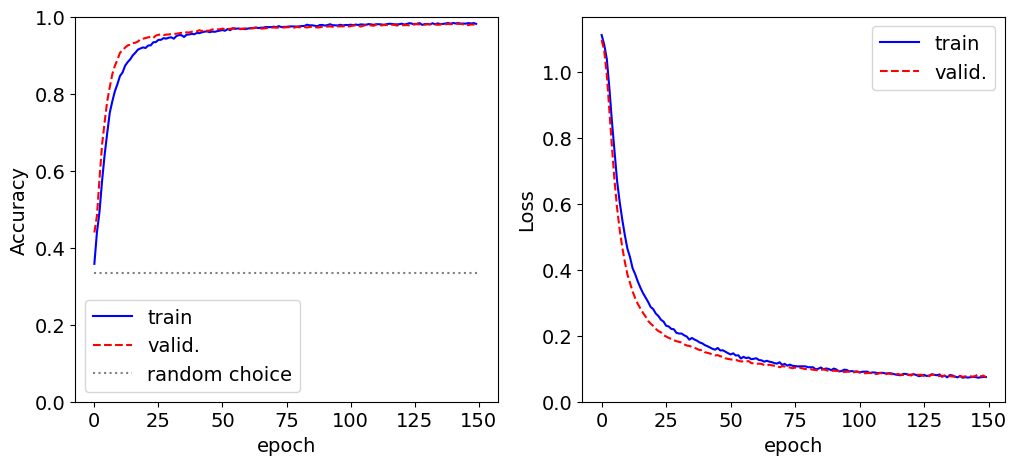

(11, 1, 5)
(5, 1, 11)


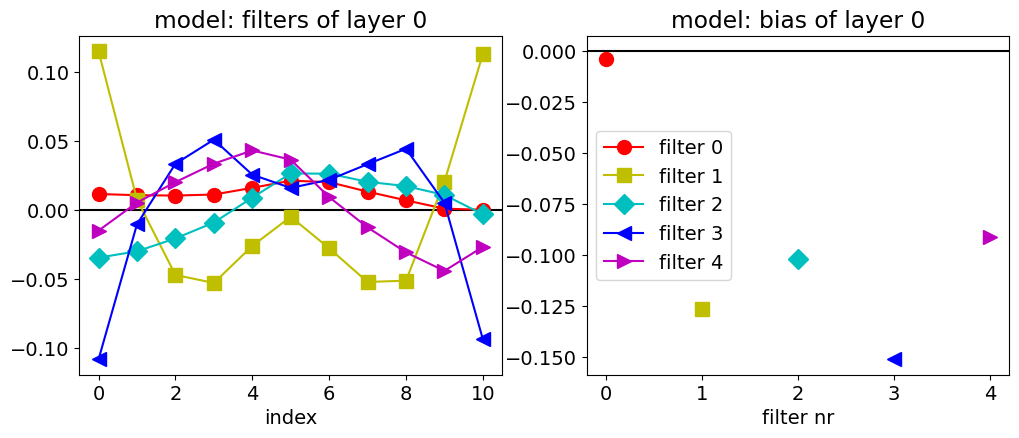

(7, 5, 5)
(5, 5, 7)


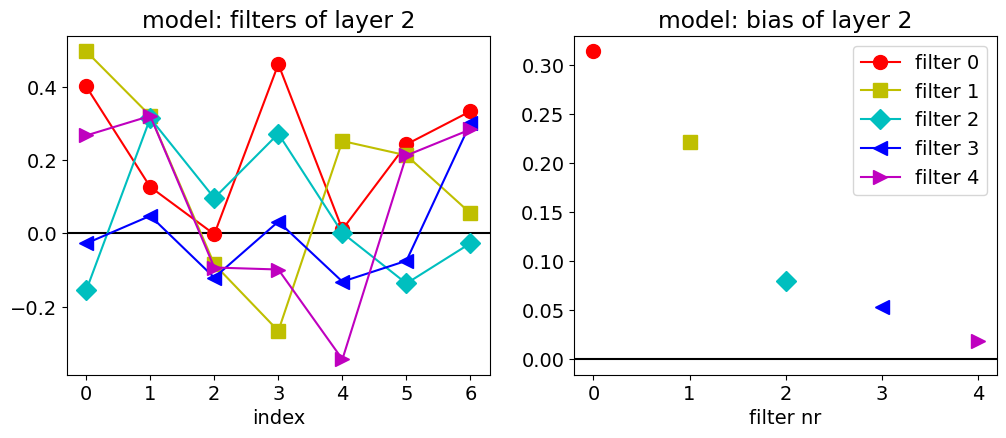

In [54]:
Show_history(fit)
Show_weights(model,0)
Show_weights(model,2)

In [55]:
# ...LESSON ...
reg2 = tf.keras.regularizers.l1(0.5)
model2 = keras.models.clone_model(model)
model2.layers[0].kernel_regularizer = reg2
model2.layers[2].kernel_regularizer = reg2
opt2 = tf.keras.optimizers.Adam()   # NEW optimizer instance
model2.compile(loss=keras.losses.categorical_crossentropy,optimizer=opt2,metrics=['accuracy'])

BATCH_SIZE2 = 200
EPOCHS2 = 150

fit2 = model2.fit(x_train,y_train,batch_size=BATCH_SIZE2,epochs=EPOCHS2,
                validation_data=(x_val, y_val), verbose=2, shuffle=True)

Epoch 1/150
40/40 - 5s - 123ms/step - accuracy: 0.3740 - loss: 1.1097 - val_accuracy: 0.4335 - val_loss: 1.0911
Epoch 2/150
40/40 - 1s - 14ms/step - accuracy: 0.4807 - loss: 1.0666 - val_accuracy: 0.5245 - val_loss: 1.0416
Epoch 3/150
40/40 - 1s - 13ms/step - accuracy: 0.5629 - loss: 1.0073 - val_accuracy: 0.6200 - val_loss: 0.9654
Epoch 4/150
40/40 - 1s - 13ms/step - accuracy: 0.6470 - loss: 0.9271 - val_accuracy: 0.7140 - val_loss: 0.8720
Epoch 5/150
40/40 - 0s - 12ms/step - accuracy: 0.7318 - loss: 0.8357 - val_accuracy: 0.8205 - val_loss: 0.7668
Epoch 6/150
40/40 - 1s - 13ms/step - accuracy: 0.7916 - loss: 0.7311 - val_accuracy: 0.8555 - val_loss: 0.6429
Epoch 7/150
40/40 - 1s - 14ms/step - accuracy: 0.8416 - loss: 0.6174 - val_accuracy: 0.8930 - val_loss: 0.5302
Epoch 8/150
40/40 - 0s - 12ms/step - accuracy: 0.8701 - loss: 0.5334 - val_accuracy: 0.9075 - val_loss: 0.4537
Epoch 9/150
40/40 - 1s - 13ms/step - accuracy: 0.8865 - loss: 0.4729 - val_accuracy: 0.9175 - val_loss: 0.4010


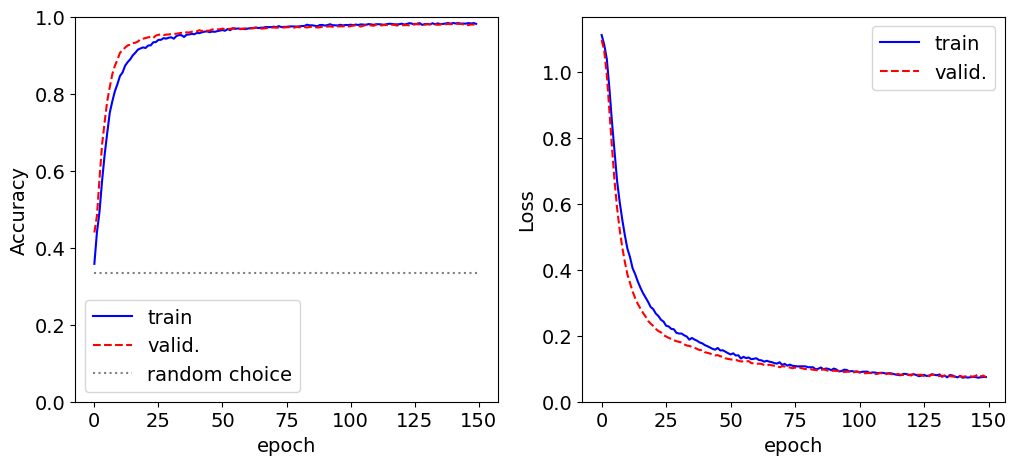

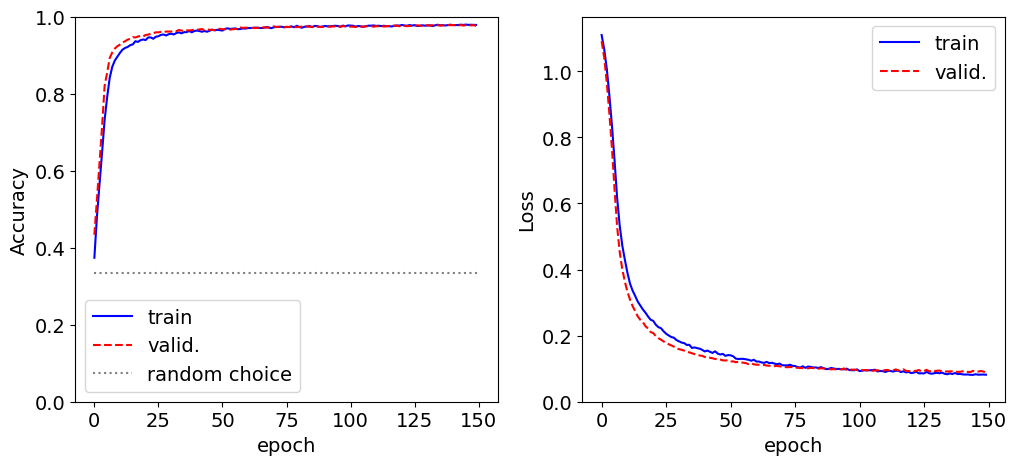

(11, 1, 5)
(5, 1, 11)


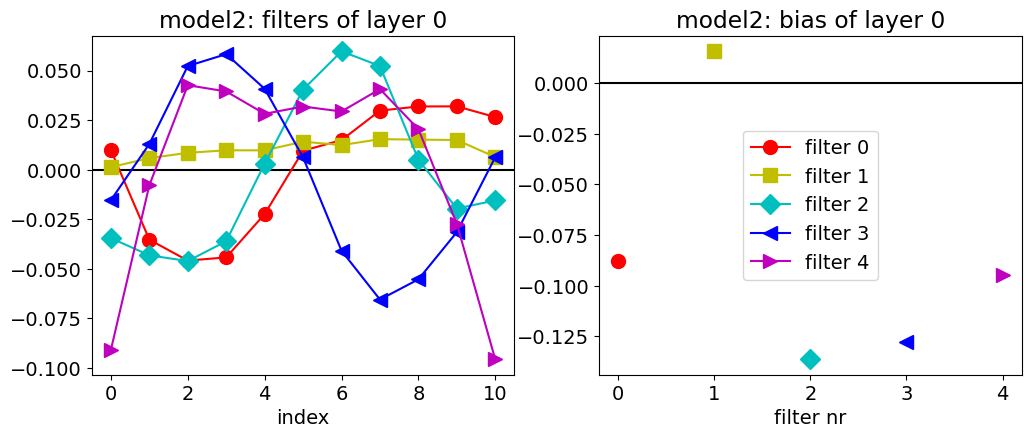

(7, 5, 5)
(5, 5, 7)


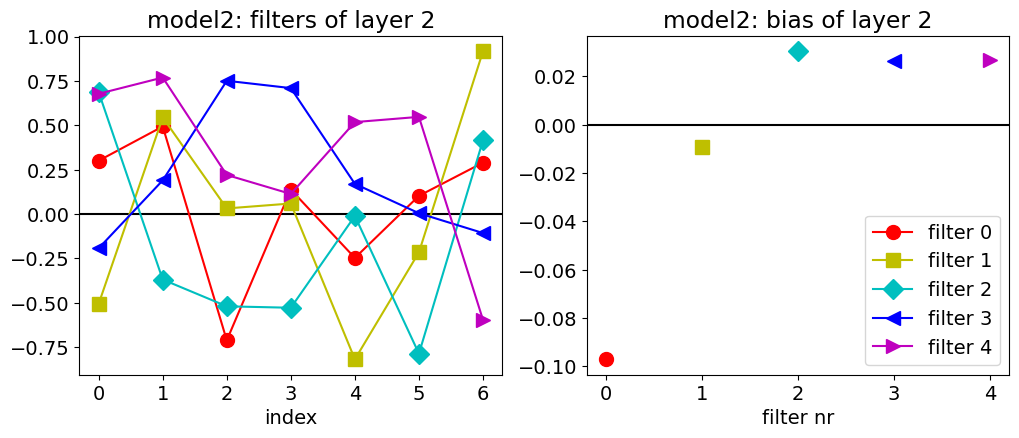

In [56]:
Show_history(fit)
Show_history(fit2)
Show_weights(model2,0,label="model2")
Show_weights(model2,2,label="model2")

In [57]:
# confusion table: compare true labels with predicted ones
import pandas as pd
from scipy import stats

import seaborn 
from sklearn import metrics

from sklearn.metrics import classification_report
from sklearn import preprocessing

LABELS = ["absent","positive","negative"] # from labels y 
cmap="GnBu"

def show_confusion_matrix(validations, predictions, label="Model"):

    matrix = metrics.confusion_matrix(validations, predictions)
    plt.figure(figsize=(6, 5))
    seaborn.heatmap(matrix,
                xticklabels=LABELS,
                yticklabels=LABELS,
                annot=True,
                fmt='d',
                linecolor='white',
                linewidths=1,
                cmap=cmap)
    plt.title(label+': Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


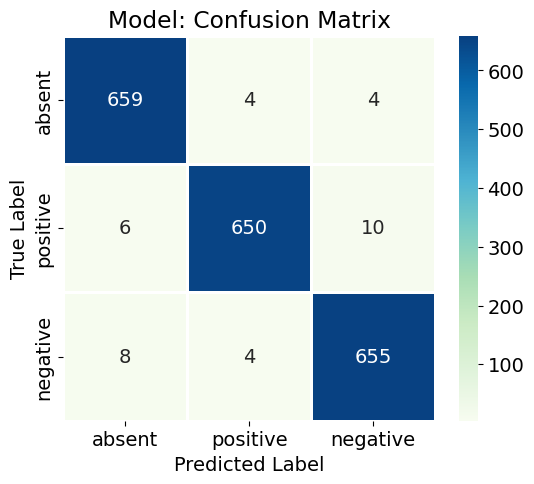

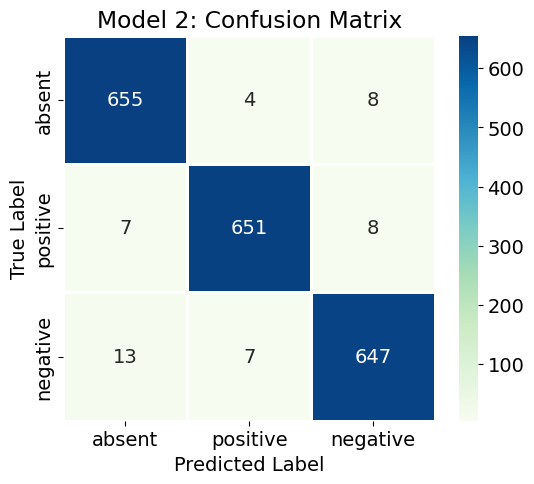

In [58]:
y_pred_val = model.predict(x_val)
y_pred_val2 = model2.predict(x_val)
# Take the class with the highest probability from the val predictions
max_y_pred_val = np.argmax(y_pred_val, axis=1)
max_y_val = np.argmax(y_val, axis=1)
max_y_pred_val2 = np.argmax(y_pred_val2, axis=1)

show_confusion_matrix(max_y_val, max_y_pred_val)
show_confusion_matrix(max_y_val, max_y_pred_val2, label="Model 2")

#print(classification_report(max_y_val, max_y_pred_val))

## 2. Performance Analysis: SNR Sensitivity Study

We evaluate the CNN's robustness by varying the **Signal-to-Noise Ratio (SNR)**. While keeping the Gaussian noise constant ($\mu=5, \sigma=50$), we test the model's accuracy across three different pattern amplitudes:

* **High SNR:** $A = 200$
* **Mid SNR:** $A = 100$
* **Low SNR:** $A = 50$ (Signal amplitude equal to noise $\sigma$)

The goal is to identify the threshold where the pattern becomes indistinguishable from the background random walk.

/home/andre/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


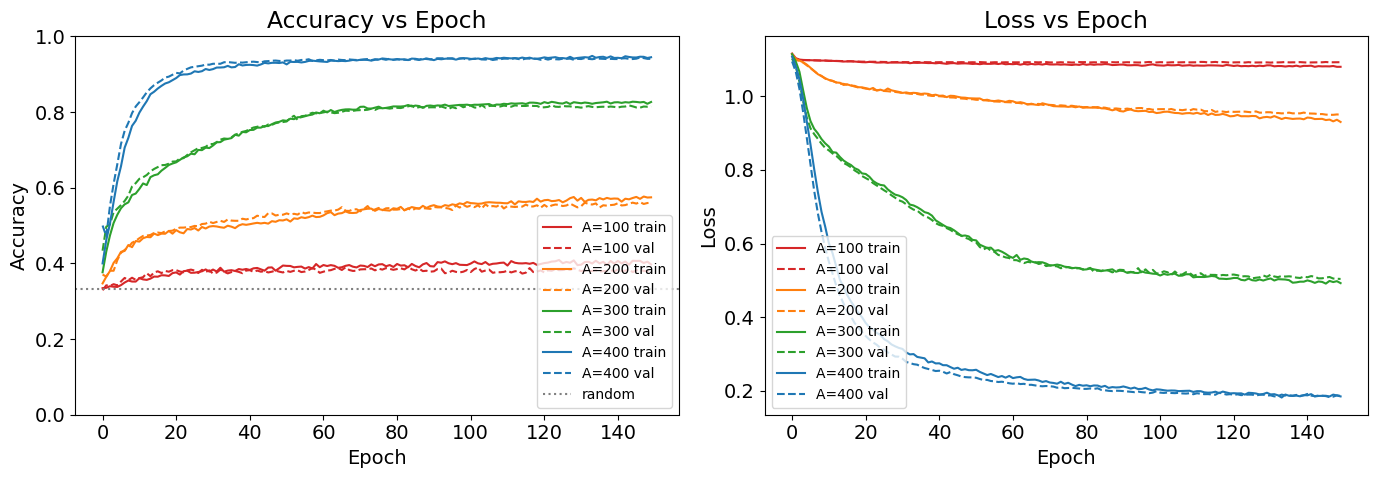

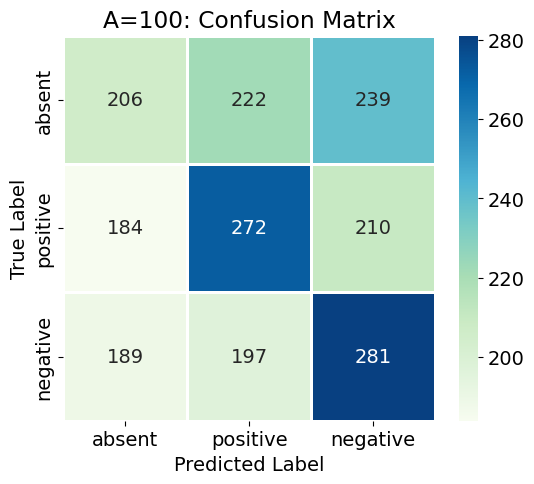

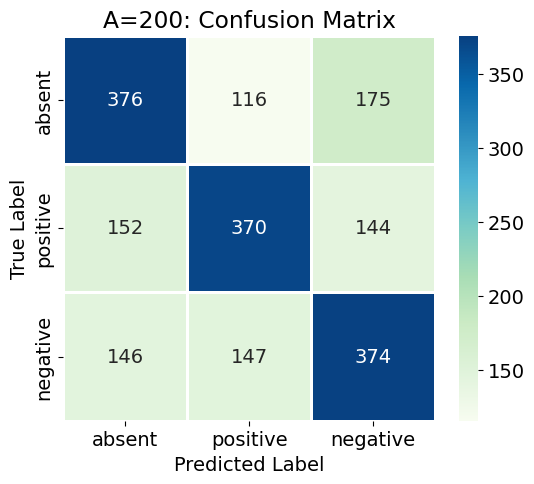

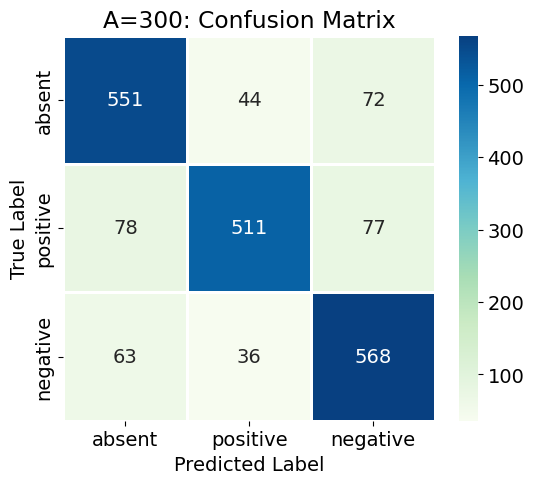

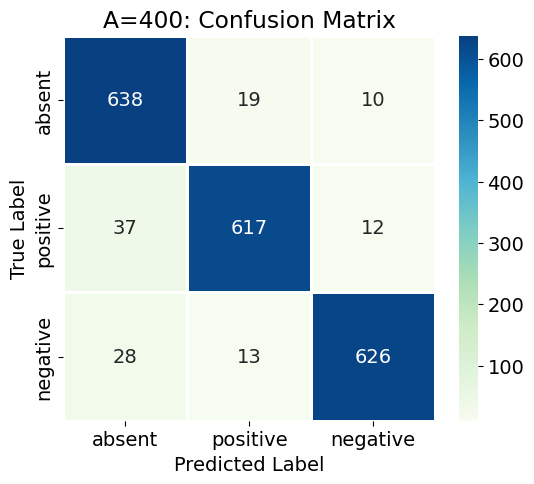

In [34]:
amplitudes = [100, 200, 300, 400]
x_datasets = [x100, x200, x300, x400]
BATCH_SIZE = 200
EPOCHS = 150

results = {}

for A, x_A in zip(amplitudes, x_datasets):
    x_A = x_A.copy()
    N_A = len(x_A)

    x_train_A, x_val_A, y_train_A, y_val_A, input_shape = split(x_A, y, N_A, L, n_class)

    np.random.seed(12345)
    tf_r.set_seed(12345)
    model_A, _ = NN(input_shape)

    fit_A = model_A.fit(x_train_A, y_train_A,
                        batch_size=BATCH_SIZE, epochs=EPOCHS,
                        validation_data=(x_val_A, y_val_A),
                        verbose=0, shuffle=True)

    results[A] = {'fit': fit_A, 'model': model_A,
                  'x_val': x_val_A, 'y_val': y_val_A}

# Learning curves
colors = {100: 'tab:red', 200: 'tab:orange', 300: 'tab:green', 400: 'tab:blue'}

fig, AX = plt.subplots(1, 2, figsize=(14, 5))
for A in amplitudes:
    fit_A = results[A]['fit']
    AX[0].plot(fit_A.history['accuracy'],     color=colors[A], ls='-',  label=f'A={A} train')
    AX[0].plot(fit_A.history['val_accuracy'], color=colors[A], ls='--', label=f'A={A} val')
    AX[1].plot(fit_A.history['loss'],         color=colors[A], ls='-',  label=f'A={A} train')
    AX[1].plot(fit_A.history['val_loss'],     color=colors[A], ls='--', label=f'A={A} val')

AX[0].axhline(1/3, color='gray', ls=':', label='random')
AX[0].set_title('Accuracy vs Epoch'); AX[0].set_xlabel('Epoch'); AX[0].set_ylabel('Accuracy')
AX[0].set_ylim([0, 1]); AX[0].legend(fontsize=10)
AX[1].set_title('Loss vs Epoch');     AX[1].set_xlabel('Epoch'); AX[1].set_ylabel('Loss')
AX[1].legend(fontsize=10)
plt.tight_layout()
plt.show()

# Confusion matrices
for A in amplitudes:
    y_pred_A = results[A]['model'].predict(results[A]['x_val'], verbose=0)
    show_confusion_matrix(np.argmax(results[A]['y_val'], axis=1),
                          np.argmax(y_pred_A, axis=1),
                          label=f"A={A}")

## results:

As the amplitude $A$ increases, the CNN performance improves consistently. At **A = 100** the model
barely exceeds the random baseline (~40% accuracy), while at **A = 400** it reaches ~95%.
The confusion matrices confirm this trend: at low $A$ misclassifications are spread across all classes,
whereas at **A = 300** and **A = 400** the diagonal becomes strongly dominant, indicating reliable
separation of all three classes. No significant overfitting is observed at any amplitude.

## 3.

## 4. CNN modeled around the best one of 2020-2021

The model uses **3 convolutional layers** (no pooling), with the intermediate Dense layer
replaced by a **GlobalMaxPooling1D**, for a total of 579 trainable parameters:

To allow a fair comparison with the results seen in class, the model was trained with
**A=500 samples** and **L2 regularization**.

In [ ]:
BATCH_SIZE = 200
EPOCHS = 150
np.random.seed(12345)
tf_r.set_seed(12345)

x_train, x_val, y_train, y_val, input_shape = split(x, y, N, L, n_class)

model4, _ = NN(input_shape, NCONV = 3)

fit = model4.fit(x_train, y_train,
                        batch_size=BATCH_SIZE, epochs=EPOCHS,
                        validation_data=(x_val, y_val),
                        verbose=0, shuffle=True)

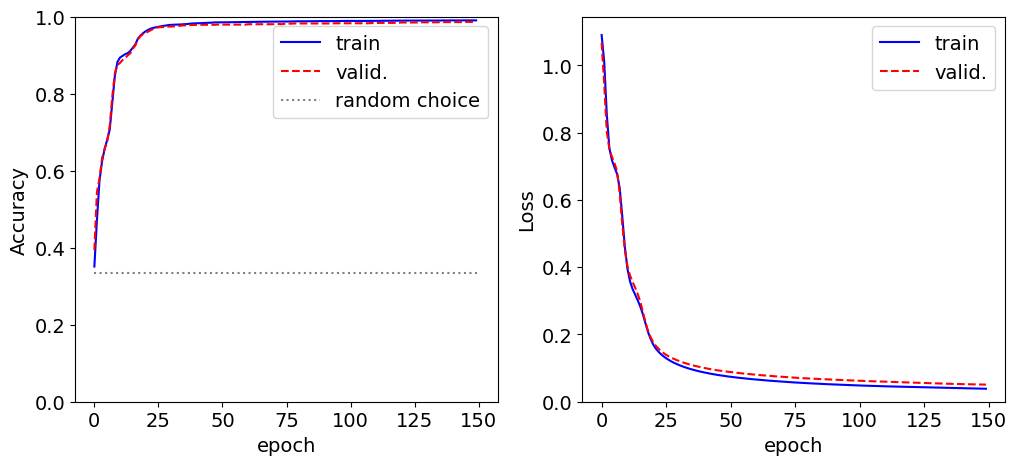

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


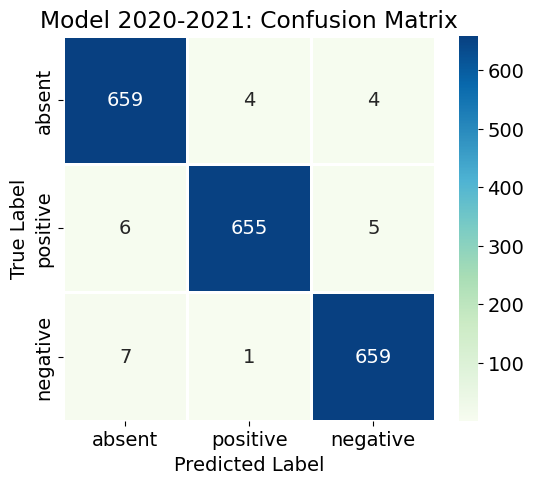

In [25]:
Show_history(fit)

y_pred_val = model4.predict(x_val)
# Take the class with the highest probability from the val predictions
max_y_pred_val = np.argmax(y_pred_val, axis=1)
max_y_val = np.argmax(y_val, axis=1)

show_confusion_matrix(max_y_val, max_y_pred_val, label = 'Model 2020-2021')

## results:

The 2020-2021 model outperforms the lesson model on all metrics:

- **Misclassified samples:** 27 vs 42 — a 36% reduction in errors
- **Accuracy:** ~ 99% vs ~ 98%, with a lower final loss (~ 0.04 vs ~ 0.07)
- **Convergence:** ~ 30 epochs vs ~ 75 epochs

This improvement is likely due to two key architectural choices:
- **GlobalMaxPooling1D** makes the model invariant to the position of the pattern within the sequence, which is beneficial when the 12-step pattern can appear anywhere in the signal
- **No intermediate pooling** preserves the full temporal resolution across all convolutional layers, allowing richer feature extraction before the final classification